## Pré Processamento

Carregando os dados

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

#importando o arquivo
df = pd.read_csv('Base_Treinamento.csv', sep=',')
df.head()


,id,data_criacao,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,BCS-00163074,2026-02-22 10:34:58.338000+00:00,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,BCS-00172400,2026-03-07 09:40:54.637000+00:00,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,BCS-00166754,2026-02-25 09:02:46.448000+00:00,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,BCS-00171257,2026-03-04 23:15:53.768443+00:00,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,BCS-00065327,2025-08-01 06:35:06.539000+00:00,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE


## Pré-processamento: eliminação de atributos irrelevantes

In [3]:
# remove as colunas id e data_criacao
df = df.drop(columns=['id','data_criacao'])

# imprime o dataframe
display(df)

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8634,Luz Queimada,2,Não,Não,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA
8636,Problema com Animal Doméstico,91,Sim,Não,Sim,URGENTE
8637,Problema com Animal Doméstico,7,Sim,Não,Sim,ALTA


Retirados os atributos id e data_criacao:

id -> Desnecessário para análise;
data_criacao -> Refeleta data de criação do chamdo, não tem relação com o atributo dias_problemas, e não deve serc onsiderado na análise, pois o chamado deve ser classificado no mesmo dia, não interferindo esse campo na classe urgencia;

Mantidos os campos:

dias_problemas -> O usuário informará quantos dias que fazem que o problema relatado no chamado existe, não necessáriamente é no mesmo dia da abertura do chamdo, pode ser antes; (Atributo contínuo)
risco_vida_humana -> Atributo descritivo, podendo ser Sim ou Não
risco_vida_animal -> Atributo descritivo, podendo ser Sim ou Não
bloqueio_via -> Atributo descritivo, podendo ser Sim ou Não

urgencia -> classe descritiva (URGENTE, ALTA, MEDIA, BAIXA)

## Pré-processamento: tratamento de atributos com valores ausentes

In [4]:
# índices das linhas que contém valores NaN
idxRowNan = pd.isnull(df).any(axis=1).to_numpy().nonzero()

# imprime apenas as linhas com valoes ausentes
display(df.iloc[idxRowNan])

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia


Nenhum atributo ausente encontrado

## Pré-processamento: tratamento de dados inconsistentes ou redundantes

In [5]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana', 'risco_vida_animal','bloqueio_via'],keep=False)]

# se houver valores redundantes ou inconsistentes, imprima
if len(df_duplicates)>0:
    print('\nAmostras redundantes ou inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


Amostras redundantes ou inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
5,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
6,Problema com Animal Selvagem,256,Sim,Sim,Não,URGENTE
...,...,...,...,...,...,...
8629,Luz Queimada Poste,4,Sim,Não,Sim,URGENTE
8632,Manutenção da Área Verde,2,Sim,Não,Não,ALTA
8633,Manutenção da Área Verde,2,Não,Sim,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA


In [6]:
def delDuplicatas(df):
   '''
   Para cada grupo de amostras duplicadas, mantém uma e apaga as demais
   '''

   # remove as amostras duplicadas, mantendo apenas a primeira ocorrencia
   df = df.drop_duplicates(keep = 'first')

   return df

df = delDuplicatas(df)

display(df)


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8630,Lixo e Detritos,4,Não,Sim,Não,ALTA
8631,Manutenção da Área Verde,3,Sim,Não,Não,ALTA
8634,Luz Queimada,2,Não,Não,Não,BAIXA
8637,Problema com Animal Doméstico,7,Sim,Não,Sim,ALTA


Removidas linhas redundantes, no total de 3228 linhas redundantes removidas

In [7]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

# para detectar inconsistências, a rotina abaixo obtém as amostras onde os valores
# dos atributos continuam duplicados. Neste caso, os atributos serão iguais, mas as classes serão distintas
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores inconsistentes, imprime
if len(df_duplicates)>0:
   print('\nAmostras inconsistentes:')
   display(df_duplicates)
else:
   print('Não existem mostras inconsistentes')



Amostras inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
42,Problema com Animal Selvagem,254,Não,Sim,Não,URGENTE
44,Problema com Animal Selvagem,254,Não,Sim,Não,ALTA
68,Problema com Animal Selvagem,252,Não,Não,Sim,ALTA
72,Problema com Animal Doméstico,252,Não,Não,Sim,URGENTE
74,Problema com Animal Doméstico,252,Não,Não,Sim,ALTA
...,...,...,...,...,...,...
8594,Árvore ou Galhos Caídos,24,Não,Sim,Não,ALTA
8604,Outros Problemas com Postes,15,Sim,Sim,Não,ALTA
8608,Problema com Animal Doméstico,2,Sim,Não,Não,ALTA
8611,Problema com Animal Doméstico,2,Sim,Não,Sim,ALTA


In [8]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

def delInconsistencias(df):
   '''
   Remove todas as amostras inconsistentes da base de dados
   '''

   df = df.drop_duplicates(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'], keep = False)
   return df

df = delInconsistencias(df)

# obtém apenas as amostras onde os valores dos atributos estão duplicados
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores redundantes ou inconsistentes, imprime
if len(df_duplicates)>0:
   display(df_duplicates)
else:
   print('Não existem amostras redundantes ou inconsistentes')

Não existem amostras redundantes ou inconsistentes


In [9]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes)


,dias_problema
count,4926.000000
mean,102.401340
std,70.082483
min,1.000000
25%,37.000000
50%,96.000000
75%,156.000000
max,256.000000


## Pré-processamento: normalização dos atributos

In [10]:
def normalizar(X):
   """
   Normaliza os atributos em X

   Esta função retorna uma versao normalizada de X onde o valor da
   média de cada atributo é igual a 0 e desvio padrao é igual a 1. Trata-se de
   um importante passo de pré-processamento quando trabalha-se com
   métodos de aprendizado de máquina.
   """

   m, n = X.shape # m = qtde de objetos e n = qtde de atributos por objeto

   # Incializa as variaves de saída
   X_norm = np.random.rand(m,n) # inicializa X_norm com valores aleatórios
   mu = 0 # inicializa a média
   sigma = 1 # inicializa o desvio padrão

   mu = np.mean(X, axis=0)
   sigma = np.std(X, axis=0, ddof=1)

   for i in range(m):
       X_norm[i,:] = (X[i,:]-mu) / sigma


   return X_norm, mu, sigma

# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia
# reovendo os atributos descritivos e classe da normalização
# coloca os valores dos atributos na variável X
X = df.iloc[:,1:-4].values

# chama a função para normalizar X
X_norm, mu, sigma = normalizar(X)

df.iloc[:,1:-4] = X_norm

print(f"\nMédia: {mu}")
print(f"Desvio padrão: {sigma}")

# Verifique se os dados estão corretos
print(f"\nTotal de amostras: {len(X)}")

print('\nPrimeira amostra da base antes da normalização: [%2.4f].' % X[0,0])
print('\nPrimeira amostra da base após normalização: [%2.4f].' % X_norm[0,0])




Média: [102.40133983]
Desvio padrão: [70.08248302]

Total de amostras: 4926

Primeira amostra da base antes da normalização: [51.0000].

Primeira amostra da base após normalização: [-0.7334].


Executada a normalização, levando a Média a 0 e o Desvio Padrão a 1.

In [11]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes.round(8))

,dias_problema
count,4926.000000
mean,0.000000
std,1.000000
min,-1.446886
25%,-0.933205
50%,-0.091340
75%,0.764794
max,2.191684


## Pré-processamento: detecção de *outliers*

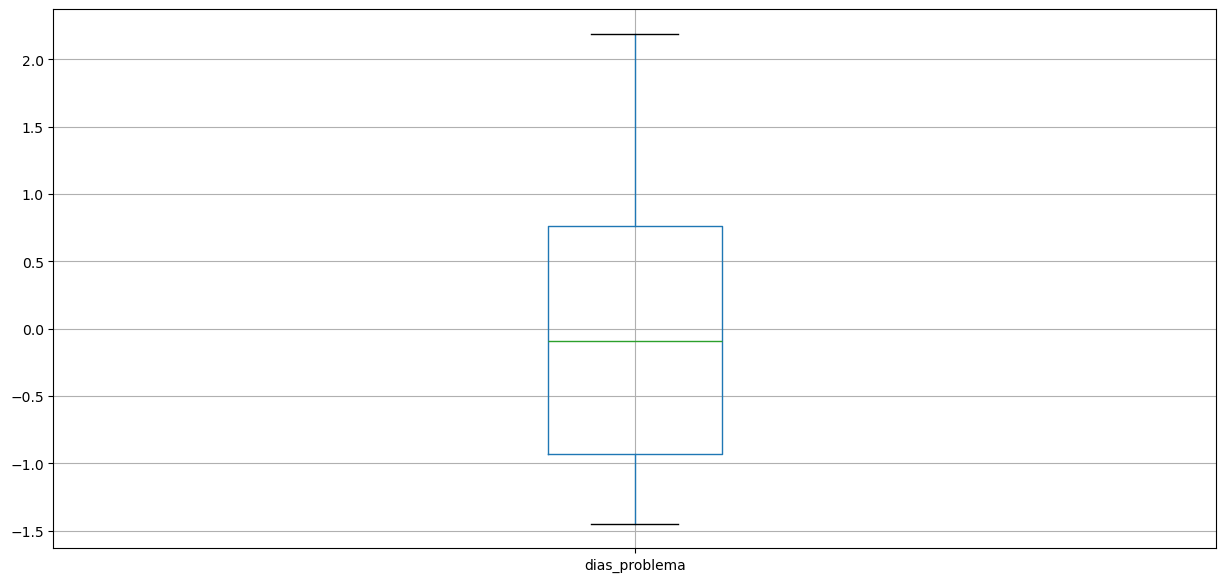

In [12]:
# gera um bloxplot para cada atributo
df.boxplot(figsize=(15,7))
plt.show()


Como Outliers não foram encontrados, não é possível verificar se são erros ou não, não é necessário remove-los

Como não há mais de um atributo numérico, não é possível gerar um gráfico de dispersão. O gráfico de dispersão é utilizado para visualizar a relação entre dois ou mais atributos numéricos.

## Pré-processamento: distribuição das classes

urgencia
URGENTE    3484
ALTA        741
MEDIA       579
BAIXA       122
Name: count, dtype: int64

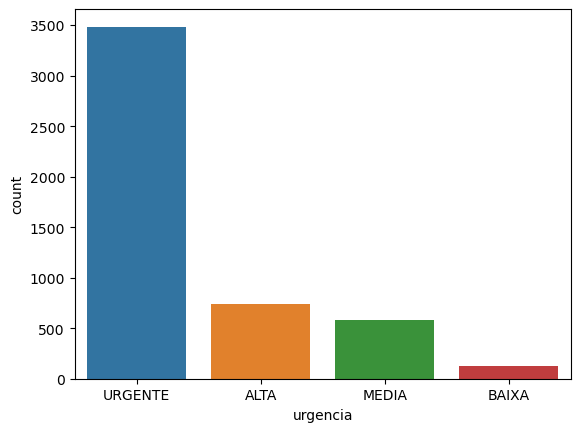

In [13]:
display(df['urgencia'].value_counts())

# cria um gráfico de barras com a frequência de cada urgencia
sns.countplot(x="urgencia", data=df)

# mostra o gráfico
plt.show()

Como somente um atributo é quantitativo, não é possivel criar uma matriz de correlação deles

## Extração Padrão

In [14]:
# importando todas as bibliotecas importantes para cálculo e criação de visualização gráfica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from pandas.plotting import scatter_matrix
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# importando o arquivo
df = pd.read_csv('Base_Treinamento.csv', sep=',')
df.head()

,id,data_criacao,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,BCS-00163074,2026-02-22 10:34:58.338000+00:00,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,BCS-00172400,2026-03-07 09:40:54.637000+00:00,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,BCS-00166754,2026-02-25 09:02:46.448000+00:00,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,BCS-00171257,2026-03-04 23:15:53.768443+00:00,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,BCS-00065327,2025-08-01 06:35:06.539000+00:00,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE


Tratamento dos Dados

In [15]:
# Remoção de colunas desnecessárias
df = df.drop(columns=['id', 'data_criacao'])

# Mapeamento e conversão automática para tipo_chamado
mapeamento_tipo = {tipo: i + 1 for i, tipo in enumerate(df['tipo_chamado'].unique())}
df['tipo_chamado'] = df['tipo_chamado'].map(mapeamento_tipo)

# Mapeamento e conversão automática para urgencia (classe)
mapeamento_urgencia = {urgencia: i for i, urgencia in enumerate(df['urgencia'].unique())}
df['urgencia'] = df['urgencia'].map(mapeamento_urgencia)

# Conversão das colunas Sim/Não
for coluna in ['risco_vida_humana', 'risco_vida_animal', 'bloqueio_via']:
    df[coluna] = df[coluna].map({'Sim': 1, 'Não': 0})

# Relatório em formato de tabela - tipo_chamado
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - tipo_chamado")
print("="*75)
print(f"{'Valor Original':<40} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
for tipo, numero in mapeamento_tipo.items():
    print(f"{str(tipo):<40} {'->':<5} {str(numero):<15}")
print("="*75)

# Relatório em formato de tabela - urgencia (classe)
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - urgencia (CLASSE)")
print("="*75)
print(f"{'Valor Original':<40} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
for urgencia, numero in mapeamento_urgencia.items():
    print(f"{str(urgencia):<40} {'->':<5} {str(numero):<15}")
print("="*75)

# Relatório das colunas Sim/Não
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - Sim/Não")
print("="*75)
print(f"{'Valor Original':<20} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
print(f"{'Sim':<20} {'->':<5} {'1':<15}")
print(f"{'Não':<20} {'->':<5} {'0':<15}")
print("="*75)
print(f"Colunas convertidas: risco_vida_humana, risco_vida_animal, bloqueio_via")
print("="*75)
print("")

# Exibir informações sobre os dados convertidos
print("\n" + "="*75)
print("RESUMO DAS CONVERSÕES REALIZADAS")
print("="*75)
print(f"✓ tipo_chamado: {len(mapeamento_tipo)} categorias convertidas")
print(f"✓ urgencia (classe): {len(mapeamento_urgencia)} categorias convertidas")
print(f"✓ risco_vida_humana: Sim/Não convertido para 1/0")
print(f"✓ risco_vida_animal: Sim/Não convertido para 1/0")
print(f"✓ bloqueio_via: Sim/Não convertido para 1/0")
print("="*75)

# Mostrar tipos de dados após conversão
print("\nTIPOS DE DADOS APÓS CONVERSÃO:")
print(df.dtypes)
print("")


TABELA DE CONVERSÃO - tipo_chamado
Valor Original                           ->    Valor Numérico 
---------------------------------------------------------------------------
Outros Problemas com Postes              ->    1              
Luz Queimada Poste                       ->    2              
Problema com Animal Doméstico            ->    3              
Problema com Animal Selvagem             ->    4              
Animal Perdido                           ->    5              
Remoção de Árvore ou Tocos               ->    6              
Poste caido                              ->    7              
Divisor de Pista                         ->    8              
Árvore ou Galhos Caídos                  ->    9              
Solicitação de Poda                      ->    10             
Solicitação de Plantio                   ->    11             
Lixo e Detritos                          ->    12             
Manutenção da Área Verde                 ->    13             
Sugest

Informações

In [16]:
# Dimensão
print(df.shape)

(8639, 6)


In [17]:
# Resumo estatístico
print(df.describe())

       tipo_chamado  dias_problema  risco_vida_humana  risco_vida_animal  \
count   8639.000000    8639.000000        8639.000000        8639.000000   
mean       4.650075     102.274453           0.479106           0.489293   
std        3.538450      69.939221           0.499592           0.499914   
min        1.000000       1.000000           0.000000           0.000000   
25%        2.000000      36.000000           0.000000           0.000000   
50%        3.000000      97.000000           0.000000           0.000000   
75%        7.000000     157.500000           1.000000           1.000000   
max       22.000000     256.000000           1.000000           1.000000   

       bloqueio_via     urgencia  
count   8639.000000  8639.000000  
mean       0.460586     0.519620  
std        0.498473     0.827185  
min        0.000000     0.000000  
25%        0.000000     0.000000  
50%        0.000000     0.000000  
75%        1.000000     1.000000  
max        1.000000     3.000000  


In [18]:
# Distribuição de classe
print(df.groupby('urgencia').size())

urgencia
0    5772
1    1500
2    1112
3     255
dtype: int64


Visualização dos dados

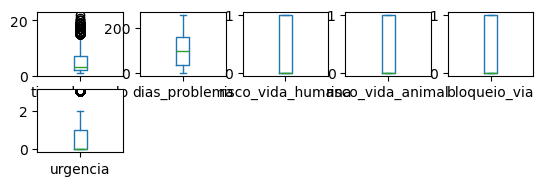

In [19]:
# gráfico de box and whisker
df.plot(kind='box', subplots=True, layout=(5,5), sharex=False, sharey=False)
plt.show()

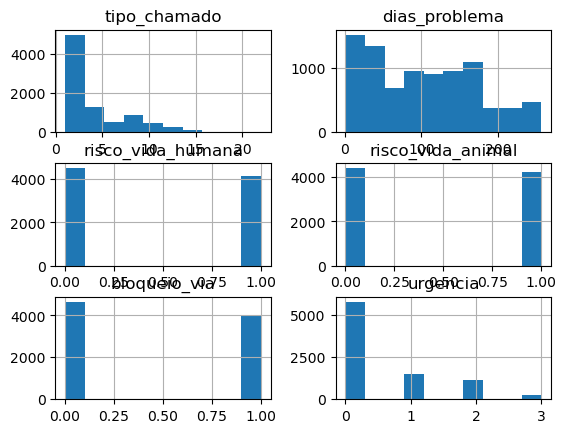

In [20]:
# histograma
df.hist()
plt.show()

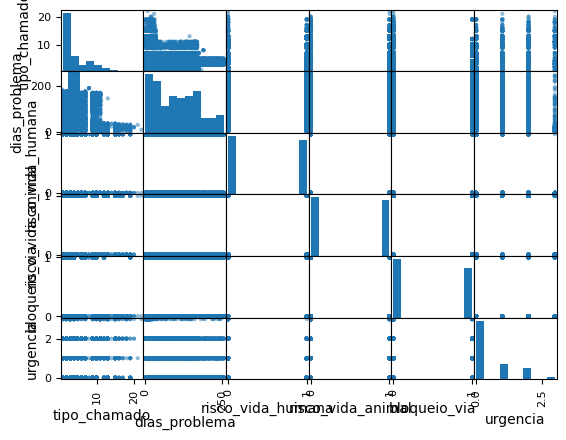

In [21]:
# gráfico de dispersão
scatter_matrix(df)
plt.show()

Criar conjunto de validação

In [22]:
# Separar features e target
X = df.drop('urgencia', axis=1).values
Y = df['urgencia'].values

# Normalizar os dados (crucial para SVM e KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dividir em treino e validação
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed, stratify=Y)

print("Shape X_train:", X_train.shape)
print("Shape Y_train:", Y_train.shape)
print("Shape X_validation:", X_validation.shape)
print("Shape Y_validation:", Y_validation.shape)
print("\nDistribuição classes no treino:", np.bincount(Y_train))
print("Distribuição classes na validação:", np.bincount(Y_validation))

Shape X_train: (6911, 5)
Shape Y_train: (6911,)
Shape X_validation: (1728, 5)
Shape Y_validation: (1728,)

Distribuição classes no treino: [4617 1200  890  204]
Distribuição classes na validação: [1155  300  222   51]


In [23]:
# Métricas
seed = 7
scoring = 'accuracy'

### Algoritmos que serão treinados
##### Regressão Logística (LR)
##### Análise Linear Discriminante (LDA)
##### K-vizinhos mais próximos (KNN)
##### Árvores de Classificação (Decision Tree) e Regressão (CART)
##### Gaussian Naive Bayes (NB)
##### Support Vector Machines (SVM)

In [24]:
# Algoritmos
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(max_depth=10, random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# Avaliação de cada modelo
results = []
names = []
for name, model in models:
   kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
   cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
   results.append(cv_results)
   names.append(name)
   msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
   print(msg)

LR: 0.784834 (0.016266)
LDA: 0.787005 (0.016191)
KNN: 0.817248 (0.010422)
CART: 0.825783 (0.015779)
NB: 0.758063 (0.068122)
SVM: 0.798581 (0.019432)


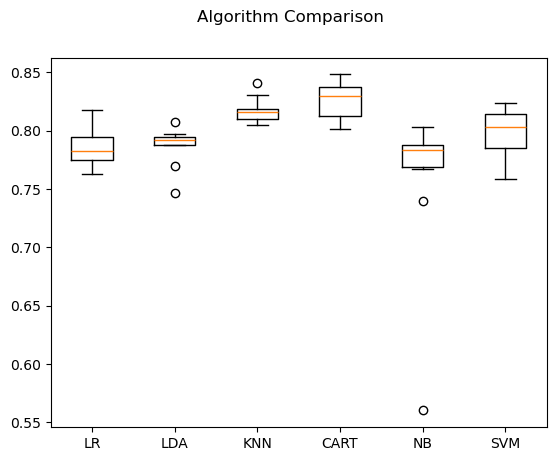

In [25]:
# Comparação dos Algoritmos
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

KNN

In [26]:
# Precisão do modelo no conjunto de treinamento
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
predictions = knn.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8690493416292866
Matriz de Confusão (Treino):
[[4426  183    8    0]
 [ 237  793  169    1]
 [  23  173  668   26]
 [   1   16   68  119]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4617
           1       0.68      0.66      0.67      1200
           2       0.73      0.75      0.74       890
           3       0.82      0.58      0.68       204

    accuracy                           0.87      6911
   macro avg       0.79      0.74      0.76      6911
weighted avg       0.87      0.87      0.87      6911



In [27]:
# Precisão do modelo no conjunto de validação
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
predictions = knn.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8130787037037037
Matriz de Confusão (Validação):
[[1081   70    4    0]
 [  85  159   56    0]
 [   7   69  140    6]
 [   0    5   21   25]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1155
           1       0.52      0.53      0.53       300
           2       0.63      0.63      0.63       222
           3       0.81      0.49      0.61        51

    accuracy                           0.81      1728
   macro avg       0.72      0.65      0.67      1728
weighted avg       0.81      0.81      0.81      1728



LR

In [28]:
# Precisão do modelo no conjunto de treinamento
lr = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)
lr.fit(X_train, Y_train)
predictions = lr.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.7846910722037331
Matriz de Confusão (Treino):
[[4476  137    4    0]
 [ 654  304  242    0]
 [ 115  133  642    0]
 [  18   17  168    1]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      4617
           1       0.51      0.25      0.34      1200
           2       0.61      0.72      0.66       890
           3       1.00      0.00      0.01       204

    accuracy                           0.78      6911
   macro avg       0.74      0.49      0.48      6911
weighted avg       0.77      0.78      0.75      6911



In [29]:
# Precisão do modelo no conjunto de validação
lr = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)
lr.fit(X_train, Y_train)
predictions = lr.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7824074074074074
Matriz de Confusão (Validação):
[[1126   28    1    0]
 [ 175   69   56    0]
 [  35   30  157    0]
 [   2    4   45    0]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1155
           1       0.53      0.23      0.32       300
           2       0.61      0.71      0.65       222
           3       0.00      0.00      0.00        51

    accuracy                           0.78      1728
   macro avg       0.49      0.48      0.47      1728
weighted avg       0.73      0.78      0.74      1728



c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


LDA

In [30]:
# Precisão do modelo no conjunto de treinamento
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)
predictions = lda.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.789755462306468
Matriz de Confusão (Treino):
[[4306  303    4    4]
 [ 467  486  236   11]
 [  58  182  603   47]
 [   1   30  110   63]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4617
           1       0.49      0.41      0.44      1200
           2       0.63      0.68      0.65       890
           3       0.50      0.31      0.38       204

    accuracy                           0.79      6911
   macro avg       0.63      0.58      0.60      6911
weighted avg       0.78      0.79      0.78      6911



In [31]:
# Precisão do modelo no conjunto de validação
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)
predictions = lda.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7945601851851852
Matriz de Confusão (Validação):
[[1089   65    1    0]
 [ 120  123   55    2]
 [  20   41  149   12]
 [   0    6   33   12]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1155
           1       0.52      0.41      0.46       300
           2       0.63      0.67      0.65       222
           3       0.46      0.24      0.31        51

    accuracy                           0.79      1728
   macro avg       0.62      0.56      0.58      1728
weighted avg       0.78      0.79      0.78      1728



CART

In [32]:
# Precisão do modelo no conjunto de treinamento
cart = DecisionTreeClassifier(max_depth=10, random_state=seed)
cart.fit(X_train, Y_train)
predictions = cart.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8755607003328028
Matriz de Confusão (Treino):
[[4448  158   11    0]
 [ 241  743  214    2]
 [   7  139  719   25]
 [   0    7   56  141]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      4617
           1       0.71      0.62      0.66      1200
           2       0.72      0.81      0.76       890
           3       0.84      0.69      0.76       204

    accuracy                           0.88      6911
   macro avg       0.80      0.77      0.78      6911
weighted avg       0.87      0.88      0.87      6911



In [33]:
# Precisão do modelo no conjunto de validação
cart = DecisionTreeClassifier(max_depth=10, random_state=seed)
cart.fit(X_train, Y_train)
predictions = cart.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8258101851851852
Matriz de Confusão (Validação):
[[1092   61    2    0]
 [  77  156   66    1]
 [   6   53  150   13]
 [   0    1   21   29]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1155
           1       0.58      0.52      0.55       300
           2       0.63      0.68      0.65       222
           3       0.67      0.57      0.62        51

    accuracy                           0.83      1728
   macro avg       0.70      0.68      0.69      1728
weighted avg       0.82      0.83      0.82      1728



NB

In [34]:
# Precisão do modelo no conjunto de treinamento
nb = GaussianNB()
nb.fit(X_train, Y_train)
predictions = nb.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.7799160758211546
Matriz de Confusão (Treino):
[[4454  154    7    2]
 [ 641  272  250   37]
 [ 100   99  531  160]
 [  15    7   49  133]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.85      0.96      0.91      4617
           1       0.51      0.23      0.31      1200
           2       0.63      0.60      0.61       890
           3       0.40      0.65      0.50       204

    accuracy                           0.78      6911
   macro avg       0.60      0.61      0.58      6911
weighted avg       0.75      0.78      0.75      6911



In [35]:
# Precisão do modelo no conjunto de validação
nb = GaussianNB()
nb.fit(X_train, Y_train)
predictions = nb.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7789351851851852
Matriz de Confusão (Validação):
[[1115   39    1    0]
 [ 173   62   55   10]
 [  27   28  131   36]
 [   1    2   10   38]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1155
           1       0.47      0.21      0.29       300
           2       0.66      0.59      0.63       222
           3       0.45      0.75      0.56        51

    accuracy                           0.78      1728
   macro avg       0.61      0.63      0.59      1728
weighted avg       0.75      0.78      0.75      1728



SVM

In [36]:
# Precisão do modelo no conjunto de treinamento
svm = SVC(gamma='auto')
svm.fit(X_train, Y_train)
predictions = svm.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8052380263348285
Matriz de Confusão (Treino):
[[4368  242    7    0]
 [ 465  468  266    1]
 [  87  122  656   25]
 [  18    6  107   73]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4617
           1       0.56      0.39      0.46      1200
           2       0.63      0.74      0.68       890
           3       0.74      0.36      0.48       204

    accuracy                           0.81      6911
   macro avg       0.70      0.61      0.63      6911
weighted avg       0.79      0.81      0.79      6911



In [37]:
# Precisão do modelo no conjunto de validação
svm = SVC(gamma='auto')
svm.fit(X_train, Y_train)
predictions = svm.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8084490740740741
Matriz de Confusão (Validação):
[[1104   50    1    0]
 [ 119  121   60    0]
 [  23   36  156    7]
 [   2    1   32   16]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1155
           1       0.58      0.40      0.48       300
           2       0.63      0.70      0.66       222
           3       0.70      0.31      0.43        51

    accuracy                           0.81      1728
   macro avg       0.70      0.59      0.62      1728
weighted avg       0.79      0.81      0.79      1728



## Algoritmo Escolhido

Como modelo para o nosso projeto, foi escolhido o CART pois apresenta os melhores resultados de precisão para treinamento (87%) e teste (82%).

Gerando o modelo que será utilizado na API.

In [41]:
# script_recriar_modelo.py
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier

# Seu código de treinamento original
seed = 42

# Recarregar seus dados (ajuste conforme seu dataset)
# df = pd.read_csv('seu_dataset.csv')
# X_train, Y_train = ... seus dados de treino

# Recriar o modelo
cart = DecisionTreeClassifier(max_depth=10, random_state=seed)
cart.fit(X_train, Y_train)

# Salvar com a versão atual
joblib.dump(cart, 'modelo_cart.pkl')

print("Modelo criado com sucesso!")

Modelo criado com sucesso!
